# Data Challenge 10 — MLR Interpretation with Adjusted R² (HVFHV Trips)


**Format:** Instructor Guidance → You Do (Students) → We Share (Reflection)

**Goal:** Build **3 MLR models** with different feature sets to predict a numeric target, then compare **Adjusted R²** and **p-values** to select the better model and justify it in business terms.

**Data:** July 1, 2023 - July 15, 2023 For Hire Vehicle Data in NYC

[July For Hire Vehicles Data](https://data.cityofnewyork.us/Transportation/2023-High-Volume-FHV-Trip-Data/u253-aew4/about_data)


## Instructor Guidance

**Hint: Use the Lecture Deck, Canvas Reading, and Docs to help you with the code**

Use this guide live; students implement below.

**Docs (quick links):**
- TLC HVFHV data dictionary (columns/meaning): https://www.nyc.gov/assets/tlc/downloads/pdf/data_dictionary_trip_records_hvfhs.pdf  
- statsmodels OLS: https://www.statsmodels.org/stable/generated/statsmodels.regression.linear_model.OLS.html  
- OLS Results (attributes like `rsquared_adj`, `pvalues`): https://www.statsmodels.org/stable/generated/statsmodels.regression.linear_model.RegressionResults.html  

### Pseudocode Plan
1) **Load CSV** → preview columns/shape; confirm target & candidate predictors exist.  
2) **Assign Y + Xs** (start small, add features with a hypothesis). Coerce **just these columns** to numeric.  
3) **Light prep:** derive `trip_time_minutes` from `trip_time` (seconds); convert flags (`shared_request_flag`, `wav_request_flag`) to 0/1 if present.  
4) **Model sets (3 total):**  
   - **Model A (parsimonious).**  
   - **Model B (adds one meaningful predictor).**  
   - **Model C (adds 1–2 more, e.g., flags).  
5) **Add intercept** and **fit** each with OLS on the same rows.  
6) **Record metrics:** `rsquared_adj`, coefficient table, and **p-values**.  
7) **Compare:** Prefer higher **Adjusted R²** and keep an eye on **p-values** (and signs/units).  
8) **Interpretation:** Write unit-based sentences **holding others constant**.  
9) **Selection rationale:** Pick the simplest model that improves **Adjusted R²** and 


## You Do — Student Section
Work in pairs. Comment your choices briefly. Keep code simple—only coerce the columns you use.

### Step 0 — Setup & Imports

In [54]:
import pandas as pd, numpy as np
import statsmodels.api as sm
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error
from pathlib import Path
import pandas as pd 
pd.set_option('display.float_format', lambda x: f'{x:,.4f}')

### Step 1 — Load CSV & Preview
- Point to your For Hire Vehicle Data 
- Print **shape** and **columns**.

**Hint: You may have to drop missing values and do a force coercion to make sure the variables stay numeric (other coding assignments may help)**

In [55]:
taxi = pd.read_csv('/Users/Marcy_Student/Desktop/marcy/DA2025_Lectures_Kevin/Mod6/data/FHV_072023 copy.csv',
low_memory=False)

In [56]:
pd.set_option('display.max_columns', None)
taxi['pickup_datetime'] = pd.to_datetime(taxi['pickup_datetime'], format="%m/%d/%Y %H:%M:%S %p")

# Creates a new column 'hour' with the hour extracted
taxi['pickup_hour'] = taxi['pickup_datetime'].dt.hour



<Axes: xlabel='pickup_hour', ylabel='base_passenger_fare'>

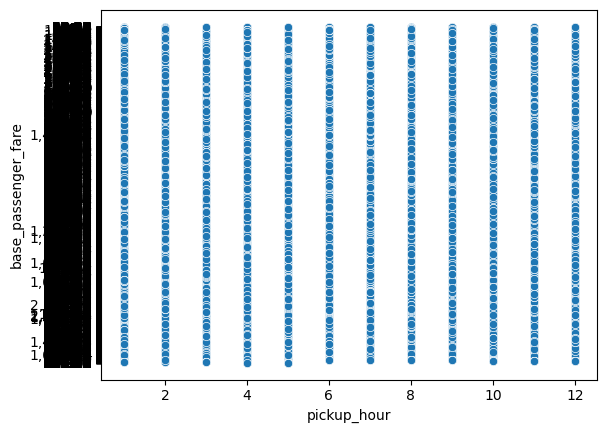

In [57]:
import seaborn as sns
import matplotlib.pyplot as plt

# Create a basic scatterplot
sns.scatterplot(x="pickup_hour", y="base_passenger_fare", data=taxi)

In [58]:
taxi.columns

Index(['hvfhs_license_num', 'dispatching_base_num', 'originating_base_num',
       'request_datetime', 'on_scene_datetime', 'pickup_datetime',
       'dropoff_datetime', 'PULocationID', 'DOLocationID', 'trip_miles',
       'trip_time', 'base_passenger_fare', 'tolls', 'bcf', 'sales_tax',
       'congestion_surcharge', 'airport_fee', 'tips', 'driver_pay',
       'shared_request_flag', 'shared_match_flag', 'access_a_ride_flag',
       'wav_request_flag', 'wav_match_flag', 'pickup_hour'],
      dtype='object')

In [59]:
# Keep only numeric and relevant columns
num_cols = ['trip_miles','trip_time', 'base_passenger_fare','airport_fee', 'tips', 'driver_pay']

for c in num_cols:
    taxi[c] = pd.to_numeric (
        taxi[c].astype(str).str.strip().str.replace(r'[^0-9.+\-eE]', '', regex=True),
        errors='coerce'
)
    
taxi.head()

,hvfhs_license_num,dispatching_base_num,originating_base_num,request_datetime,on_scene_datetime,pickup_datetime,dropoff_datetime,PULocationID,DOLocationID,trip_miles,trip_time,base_passenger_fare,tolls,bcf,sales_tax,congestion_surcharge,airport_fee,tips,driver_pay,shared_request_flag,shared_match_flag,access_a_ride_flag,wav_request_flag,wav_match_flag,pickup_hour
0,HV0005,B03406,NaN,07/01/2023 05:34:30 PM,NaN,2023-07-01 05:37:48,07/01/2023 05:44:45 PM,158,68,1.2660,417,15.1800,0.0000,0.4200,1.3500,2.7500,0.0000,2.0000,5.5700,N,N,N,N,False,5
1,HV0003,B03404,B03404,07/01/2023 05:34:30 PM,07/01/2023 05:36:53 PM,2023-07-01 05:37:15,07/01/2023 05:55:15 PM,162,234,2.3500,1080,17.1500,0.0000,0.4700,1.5200,2.7500,0.0000,3.2800,13.3800,N,N,NaN,N,False,5
2,HV0003,B03404,B03404,07/01/2023 05:34:30 PM,07/01/2023 05:35:17 PM,2023-07-01 05:35:52,07/01/2023 05:44:27 PM,161,163,0.8100,515,5.5700,0.0000,0.1500,0.4900,2.7500,0.0000,0.0000,5.9500,N,N,NaN,N,False,5
3,HV0003,B03404,B03404,07/01/2023 05:34:30 PM,07/01/2023 05:37:39 PM,2023-07-01 05:39:35,07/01/2023 06:23:02 PM,122,229,15.4700,2607,58.2300,0.0000,1.6000,5.1700,2.7500,0.0000,0.0000,54.4600,N,N,NaN,N,True,5
4,HV0003,B03404,B03404,07/01/2023 05:34:30 PM,07/01/2023 05:36:06 PM,2023-07-01 05:36:39,07/01/2023 05:45:06 PM,67,14,1.5200,507,9.6100,0.0000,0.2600,0.8500,0.0000,0.0000,3.0000,7.0100,N,N,NaN,N,False,5


### Step 2 —  Choose Target **Y** and Candidate Predictors

- Suggested **Y**: `base_passenger_fare` (USD).
- Start with **distance** and **time**; optionally add **flags** if present.
- Derive `trip_time_minutes` from `trip_time` (seconds) if available.

In [60]:
Y = taxi['base_passenger_fare']

### Step 3 — Define Three Model Specs (A, B, C)
Example models you can chose any models you want as long as Model A has one term, Model B two terms, etc.

- **Model A:** distance only.  
- **Model B:** distance + time (minutes).  
- **Model C:** distance + time + flags (whichever exist).

In [61]:
from sklearn.linear_model import LinearRegression

# Model A - trip_time
X = sm.add_constant(taxi['trip_time']).astype(float)
X_train, X_test, y_train, y_test = train_test_split(X,Y, random_state=42, train_size=.80)
res1 = sm.OLS(Y,X).fit()

# Model B trip_time & trip_miles
X2 = sm.add_constant(taxi[['trip_time','trip_miles']]).astype(float)
X2_train, X2_test, y2_train, y2_test = train_test_split(X2, Y, random_state=42, train_size=.80)
res2 = sm.OLS(Y,X2).fit()

# Model C trip_time + trip_miles + pickup_hour
X3 = sm.add_constant(taxi[['trip_time','trip_miles','pickup_hour']]).astype(float)
X3_train, X3_test, y3_train, y3_test = train_test_split(X3, Y, random_state=42, train_size=.80)
res3 = sm.OLS(Y,X3).fit()



In [62]:
# Filter for outliers in the X, X2 and X3 train
X_train = X_train.dropna()
X2_train = X2_train.dropna()
X3_train = X3_train.dropna()

# Filter trip_time from greater than 0 to less than 20,000 in X_train
X_train = X_train[
    (X_train['trip_time'] > 0 ) & (X_train['trip_time'] <= 20000 )              # remove negative/zero fares
].copy()

# Filter trip_time from greater than 0 to less than 20,000 in X2_train
# Filter trip_miles from greater than 0 to less than 300 in X2_train
X2_train = X2_train[
    (X2_train['trip_time'] > 0 ) & (X2_train['trip_time'] <= 20000) &
    (X2_train['trip_miles'] > 0 ) & (X2_train['trip_miles'] <= 300)              # remove negative/zero fares
].copy()

# Filter trip_time from greater than 0 to less than 20,000 in X3_train
# Filter trip_miles from greater than 0 to less than 300 in X3_train
X3_train = X3_train[
    (X3_train['trip_time'] > 0 ) & (X3_train['trip_time'] <= 20000) &
    (X3_train['trip_miles'] > 0 ) & (X3_train['trip_miles'] <= 300)              # remove negative/zero fares
].copy()

### Step 4 — Fit Each Model (with intercept) and Collect Adjusted R² & p-values


In [63]:
import pandas as pd
import numpy as np

# Suppress floating-point warnings
np.seterr(divide='ignore', over='ignore', invalid='ignore')

#summary table with r^2 and adjusted r^2
def summarize_model(name, res):
    return {
        'Model': name,
        'R²': res.rsquared,
        'Adj R²': res.rsquared_adj
    }

# table with p_values and coef
def coef_table(name, res):
    df = pd.DataFrame({
        'Model': name,
        'Feature': res.params.index,
        'Coefficient': res.params.values,
        'p-value': res.pvalues.values
    })
    return df

model_summaries = [
    summarize_model('Model A', res1),
    summarize_model('Model B', res2),
    summarize_model('Model C', res3)
]

# creates df of all summaries 
summary_df = pd.DataFrame(model_summaries)

coef_df = pd.concat([
    coef_table('Model A', res1),
    coef_table('Model B', res2),
    coef_table('Model C', res3)
]).reset_index(drop=True)

# merges to make one summary table with all models and their respective values
combined_df = coef_df.merge(summary_df, on='Model', how='left')

# Round numbers for readability
combined_df = combined_df.round(5)

display(combined_df)

,Model,Feature,Coefficient,p-value,R²,Adj R²
0,Model A,const,-0.5691,0.0000,0.7026,0.7026
1,Model A,trip_time,0.0213,0.0000,0.7026,0.7026
2,Model B,const,3.3276,0.0000,0.8431,0.8431
3,Model B,trip_time,0.0081,0.0000,0.8431,0.8431
4,Model B,trip_miles,2.2063,0.0000,0.8431,0.8431
5,Model C,const,3.4096,0.0000,0.8432,0.8432
6,Model C,trip_time,0.0081,0.0000,0.8432,0.8432
7,Model C,trip_miles,2.2067,0.0000,0.8432,0.8432
8,Model C,pickup_hour,-0.0115,0.0000,0.8432,0.8432


### Step 5 — Inspect Full Summaries (coefficients, p-values, diagnostics)

- Print summaries for the top 1–2 models by **Adjusted R²**.
- Write **unit-based** interpretations “holding others constant.”

In [ ]:
# sorts the models based on the adj r^2 based on only 1 feature
# from highest to lowest adj r^2
model_scores = (
    combined_df[['Model', 'Adj R²']]
    .drop_duplicates()
    .sort_values(by='Adj R²', ascending=False)
)

# Selects two top models
top_models = model_scores.head(2)['Model'].tolist()
# Pulls from the combined_df the top two models
top_models_df = combined_df[combined_df['Model'].isin(top_models)]

display(top_models_df)


,Model,Feature,Coefficient,p-value,R²,Adj R²
2,Model B,const,3.3276,0.0000,0.8431,0.8431
3,Model B,trip_time,0.0081,0.0000,0.8431,0.8431
4,Model B,trip_miles,2.2063,0.0000,0.8431,0.8431
5,Model C,const,3.4096,0.0000,0.8432,0.8432
6,Model C,trip_time,0.0081,0.0000,0.8432,0.8432
7,Model C,trip_miles,2.2067,0.0000,0.8432,0.8432
8,Model C,pickup_hour,-0.0115,0.0000,0.8432,0.8432


Model C shows that trip_miles adds about $2.21 dollars to base_fare while holding all other factors constant. 

Mode B shows that trip_time adds about 0.81 cents to base_fare for each addition minute added to the ride.

### Step 6 — Interpretations (write below)

Using the **best model’s** coefficients interpret each coefficient using markdown

## We Share — Reflection & Wrap‑Up

Write **2 short paragraphs** and be specific:

1) **Which model (A/B/C) do you pick and why?**  
Reference **Adjusted R²** (higher is better when comparing models with different numbers of predictors) and the **p-values**/signs of key coefficients.

- 1. I would choose **Model C** because it has the **highest Adjusted R² (0.8432)**, meaning it explains slightly more variation in fares than Models A or B, even after accounting for its extra variable. All of its predictors have **very low p-values (below 0.001)**, showing they are statistically significant. The signs of the coefficients also make sense—fares increase with both **trip time** and **trip miles**, while the small negative coefficient on **pickup hour** suggests that rides later in the day tend to cost a bit less.

2) **Business explanation:**  
Give a stakeholder-friendly summary in **units** (e.g., “+1 mile ≈ +$X in base fare, holding time constant”). If you added flags, explain their effect plainly. Mention any limitations (e.g., time vs distance confounding, missing columns).
- 2. From a business perspective, this model tells us that, on average, **each additional mile adds about $2.21 to the fare**, and **each extra minute adds about $0.81**, holding other factors constant. The **base fare** starts around $3.40, and fares slightly decrease by about **1 cent per hour later in the day**. This means longer and farther trips drive revenue the most, while time of day has only a small impact. Distance and time are closely related, so the model can’t fully separate their effects, and other factors like traffic or surge pricing may also influence fares but aren’t included here.
